# 추론 방식 비교 — 베이스라인 `generate()` vs 디코딩 수정 vs 로짓 비교

재활용품 VQA 챌린지. 지금까지의 86.3%는 **로짓 비교**로 잰 값이고,
배포 베이스라인은 **`generate()` + 전체 시퀀스 디코딩 + 파싱**을 씁니다. 그 격차를 실제로 잽니다.

## 배포 베이스라인 추론의 결함

```python
out_ids = model.generate(**inputs, max_new_tokens=2, do_sample=False, ...)
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]   # ← 전체 시퀀스
preds.append(extract_choice(output_text))
```

`out_ids`에는 **입력 프롬프트가 그대로 포함**돼 있는데 그걸 통째로 디코딩합니다.
그래서 `extract_choice`가 보는 마지막 줄은 모델이 생성한 답이 아니라
`"...출력하세요."` → `"assistant"` → 생성분이 뒤섞인 문자열입니다.
생성이 비면 마지막 줄이 `"assistant"`가 되고, 파싱은 실패해 **무조건 `"a"`** 로 찍힙니다.

올바른 방식은 새로 생성된 토큰만 잘라내는 것입니다.

```python
gen_ids = out_ids[:, inputs["input_ids"].shape[1]:]        # ← 프롬프트 제거
output_text = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
```

## 설계 — 2 모델 × 3 방식

| | ① generate + 전체 디코딩 | ② generate + 새 토큰만 | ③ 로짓 비교 |
|---|---|---|---|
| **Qwen2.5-VL-3B** | **A** ← 배포 베이스라인 원본 | **A′** | **B** (= 77.3%, 기측정) |
| **Qwen3-VL-4B** | **C** | **C′** | **D** (= 86.3%, 기측정) |

②를 넣은 이유: ①과 ③만 비교하면 *"generate가 나쁘다"*와 *"베이스라인의 디코딩이 잘못됐다"*를
구분할 수 없습니다. ②가 그 둘을 갈라줍니다.

**개선폭 분해 (A → D)**

```
A  배포 베이스라인 원본
└─ +(A′−A)  디코딩 버그 수정분
   └─ +(B−A′)  로짓 방식 전환분
      └─ +(D−B)  모델 교체분  →  D 최종
```

같은 val 299장 · 같은 프롬프트 · 같은 이미지 로딩 · 학습 없음.
예상 소요: 모델 로딩 2회 + generate 4회(각 2~4분) + 로짓 2회(각 1분) ≈ **15~25분**.

> ⚠️ 학습은 하지 않습니다. 추론 방식만 비교합니다.
> 별도 이슈로 **베이스라인의 학습 라벨 마스킹 누락**(`labels = input_ids.clone()`)이 있는데,
> 그건 이 노트북의 범위가 아니라 학습 노트북(Step 4)에서 다룹니다.


---
## 0. 환경


In [1]:
# 최초 1회만 실행 → 커널 재시작
# !pip install -q -U "transformers>=4.57.0" accelerate pillow pandas scikit-learn matplotlib tqdm

In [2]:
import os, gc, json, math, random, re, time, warnings, inspect, subprocess, importlib, sys
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None

import transformers
print("transformers :", transformers.__version__)
print("torch        :", torch.__version__)
assert torch.cuda.is_available(), "GPU가 필요합니다"

CC       = torch.cuda.get_device_capability(0)
GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1024**3
DTYPE    = torch.bfloat16 if CC[0] >= 8 else torch.float16   # T4 등은 fp16
print(f"GPU          : {GPU_NAME} (cc {CC[0]}.{CC[1]}, {VRAM_GB:.1f}GB)")
print(f"dtype        : {str(DTYPE).split('.')[-1]}")

transformers : 4.57.6
torch        : 2.7.0+cu128
GPU          : NVIDIA GeForce RTX 5060 Ti (cc 12.0, 15.9GB)
dtype        : bfloat16


---
## 1. 설정

**기존 베이크오프와 동일한 split이어야 합니다.** `SEED` / `VAL_FRAC` / `N_VAL`을 바꾸면
이미 측정한 B(77.3%)·D(86.3%)와 나란히 놓을 수 없습니다.


In [3]:
DATA_DIR   = Path(".")                  # train.csv / train 폴더가 있는 경로
OUT_DIR    = Path("bakeoff_out"); OUT_DIR.mkdir(exist_ok=True)

SEED       = 42
N_VAL      = 300      # 기존 베이크오프와 동일 (실제 층화추출 결과 299장)
VAL_FRAC   = 0.10
IMAGE_SIZE = 384      # 베이스라인과 동일
MAX_LEN    = 4096
LOGIT_BATCH = 4       # 로짓 방식만 배치 처리. generate는 베이스라인처럼 1장씩
FORCE_RERUN = False   # True면 저장된 결과 무시하고 다시 측정

# 베이스라인 generate 설정 (원본 그대로)
GEN_MAX_NEW_TOKENS = 2
GEN_DO_SAMPLE      = False

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODELS = [
    {"key": "qwen3vl_4b",  "id": "Qwen/Qwen3-VL-4B-Instruct",   "label": "Qwen3-VL-4B"},
    {"key": "qwen25vl_3b", "id": "Qwen/Qwen2.5-VL-3B-Instruct", "label": "Qwen2.5-VL-3B"},
]
METHODS = ["generate_full", "generate_new", "logit"]   # ①배포원본 ②디코딩수정 ③로짓
LETTERS = ["a", "b", "c", "d"]

print("조건:", len(MODELS), "모델 ×", len(METHODS), "방식 =", len(MODELS)*len(METHODS), "회 측정")
print("방식: generate_full=배포 베이스라인 원본 / generate_new=디코딩 수정 / logit=로짓 비교")

조건: 2 모델 × 3 방식 = 6 회 측정
방식: generate_full=배포 베이스라인 원본 / generate_new=디코딩 수정 / logit=로짓 비교


---
## 2. 데이터 & split (기존과 동일)


In [4]:
train_df = pd.read_csv(DATA_DIR / "train.csv")

def qtype(q):
    q = str(q)
    if "몇" in q:   return "개수"
    if "재질" in q: return "재질"
    if "색" in q:   return "색상"
    return "기타"

train_df["qtype"] = train_df["question"].map(qtype)

rng  = np.random.RandomState(SEED)
perm = rng.permutation(len(train_df))
k    = int(len(train_df) * VAL_FRAC)
val_full = train_df.iloc[perm[:k]].reset_index(drop=True)

_parts = []
for qt, g in val_full.groupby("qtype"):
    take = max(1, min(len(g), round(N_VAL * len(g) / len(val_full))))
    _parts.append(g.sample(take, random_state=SEED))
val_df = pd.concat(_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

GOLD = val_df["answer"].str.strip().str.lower().values
print(f"val {len(val_df)}장  (기존 베이크오프와 동일해야 함: 299)")
print("정답 위치 분포:", {L: int((GOLD == L).sum()) for L in LETTERS})

val 299장  (기존 베이크오프와 동일해야 함: 299)
정답 위치 분포: {'a': 83, 'b': 73, 'c': 63, 'd': 80}


---
## 3. 프롬프트 & 이미지 로딩

**두 방식에 완전히 동일하게 적용합니다.** 여기서 달라지면 추론 방식의 순수한 효과를 못 잽니다.


In [5]:
SYSTEM_INSTRUCT = (
    "You are a helpful visual question answering assistant. "
    "Answer using exactly one letter among a, b, c, or d. No explanation."
)

def build_mc_prompt(row):
    return (
        f"{row['question']}\n"
        f"(a) {row['a']}\n(b) {row['b']}\n(c) {row['c']}\n(d) {row['d']}\n\n"
        "정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요."
    )

def load_image(row):
    img = Image.open(DATA_DIR / row["path"]).convert("RGB")
    img.thumbnail((IMAGE_SIZE * 2, IMAGE_SIZE * 2), Image.BICUBIC)
    return img

def build_messages(row):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_INSTRUCT}]},
        {"role": "user",   "content": [{"type": "image"},
                                       {"type": "text", "text": build_mc_prompt(row)}]},
    ]

print(build_mc_prompt(val_df.iloc[0]))

사진 속 재활용품 중 가장 많이 보이는 재질은 무엇인가요?
(a) 금속
(b) 유리
(c) 플라스틱
(d) 종이

정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요.


---
## 4. 베이스라인 파서 복제 + 계측

`extract_choice`는 배포 베이스라인 코드 **원본 그대로**입니다.
여기에 "파싱에 성공했는지"만 함께 돌려주는 계측 버전을 추가합니다 (판정 로직은 동일).


In [6]:
def extract_choice(text: str) -> str:
    """배포 베이스라인 원본 그대로."""
    text = text.strip().lower()
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if not lines:
        return "a"
    last = lines[-1]
    if last in ["a", "b", "c", "d"]:
        return last
    tokens = last.split()
    for tok in tokens:
        if tok in ["a", "b", "c", "d"]:
            return tok
    return "a"                      # ← 파싱 실패 시 무조건 "a"


def extract_choice_traced(text: str):
    """(선택, 파싱성공여부). 반환하는 선택은 위 원본과 항상 동일."""
    t = text.strip().lower()
    lines = [l.strip() for l in t.splitlines() if l.strip()]
    if not lines:
        return "a", False
    last = lines[-1]
    if last in ["a", "b", "c", "d"]:
        return last, True
    for tok in last.split():
        if tok in ["a", "b", "c", "d"]:
            return tok, True
    return "a", False                # 실패 → 기본값 "a"


# --- 단위 테스트: 계측 버전이 원본과 항상 같은 답을 내는지 ---
_cases = [
    ("c", "c", True), ("  C  ", "c", True), ("assistant\nb", "b", True),
    ("정답은 (c)입니다", "a", False),        # 괄호가 붙으면 토큰 매칭 실패 → 기본값
    ("정답은 c 입니다", "c", True),
    ("", "a", False), ("\n\n", "a", False),
    ("...출력하세요.\nassistant", "a", False),   # 생성이 비었을 때
    ("...출력하세요.\nassistant\nd", "d", True),
    ("The answer is D", "d", True),         # lower 후 마지막 토큰이 'd' → 매칭 성공
]
ok = True
for txt, exp_choice, exp_parsed in _cases:
    c1 = extract_choice(txt)
    c2, parsed = extract_choice_traced(txt)
    tag = "OK " if (c1 == c2 == exp_choice and parsed == exp_parsed) else "FAIL"
    if tag == "FAIL": ok = False
    print(f"  {tag} {txt!r:<34} → {c1!r} (parsed={parsed})  기대 {exp_choice!r}/{exp_parsed}")
print("\n단위 테스트", "통과" if ok else "실패 — 기대값을 확인하세요")

  OK  'c'                                → 'c' (parsed=True)  기대 'c'/True
  OK  '  C  '                            → 'c' (parsed=True)  기대 'c'/True
  OK  'assistant\nb'                     → 'b' (parsed=True)  기대 'b'/True
  OK  '정답은 (c)입니다'                       → 'a' (parsed=False)  기대 'a'/False
  OK  '정답은 c 입니다'                        → 'c' (parsed=True)  기대 'c'/True
  OK  ''                                 → 'a' (parsed=False)  기대 'a'/False
  OK  '\n\n'                             → 'a' (parsed=False)  기대 'a'/False
  OK  '...출력하세요.\nassistant'             → 'a' (parsed=False)  기대 'a'/False
  OK  '...출력하세요.\nassistant\nd'          → 'd' (parsed=True)  기대 'd'/True
  OK  'The answer is D'                  → 'd' (parsed=True)  기대 'd'/True

단위 테스트 통과


---
## 5. 모델 로딩

`auto_map` 기반 클래스 해석 + flash_attention 우회를 그대로 씁니다
(베이크오프 노트북과 동일한 코드).


In [7]:
from transformers import AutoProcessor

_FLASH = {"flash_attention_2", "flash_attention_3"}


def _scrub_flash_attn(cfg, impl):
    seen = set()
    def walk(c):
        if c is None or id(c) in seen or not hasattr(c, "to_dict"): return
        seen.add(id(c))
        for a in ("_attn_implementation", "attn_implementation"):
            if getattr(c, a, None) in _FLASH:
                try: setattr(c, a, impl)
                except Exception: pass
        try: c._attn_implementation = impl
        except Exception: pass
        for v in list(vars(c).values()):
            if hasattr(v, "to_dict"): walk(v)
    walk(cfg); return cfg


@contextmanager
def no_flash_attention(impl="eager", verbose=False):
    from transformers.modeling_utils import PreTrainedModel as PM
    NAMES = ("_from_config", "_check_and_adjust_attn_implementation",
             "_autoset_attn_implementation")
    saved = {}
    def coerce(a, kw):
        a = [impl if (isinstance(v, str) and v in _FLASH) else v for v in a]
        for k, v in list(kw.items()):
            if isinstance(v, str) and v in _FLASH: kw[k] = impl
            elif k == "use_flash_attention_2":     kw[k] = False
        for v in list(a) + list(kw.values()):
            if hasattr(v, "to_dict"): _scrub_flash_attn(v, impl)
        return a, kw
    for name in NAMES:
        raw = inspect.getattr_static(PM, name, None)
        if raw is None: continue
        saved[name] = (raw, name in PM.__dict__)
        is_cm, is_sm = isinstance(raw, classmethod), isinstance(raw, staticmethod)
        fn = raw.__func__ if (is_cm or is_sm) else raw
        def make(fn=fn):
            def wrapper(first, *a, **kw):
                a, kw = coerce(list(a), kw)
                return fn(first, *a, **kw)
            return wrapper
        w = make()
        setattr(PM, name, classmethod(w) if is_cm else (staticmethod(w) if is_sm else w))
    try:
        yield
    finally:
        for name, (raw, own) in saved.items():
            if own: setattr(PM, name, raw)
            else:
                try: delattr(PM, name)
                except AttributeError: pass


def _resolve_model_class(model_id, verbose=True):
    from transformers import AutoConfig
    KEYS = ("AutoModelForVision2Seq", "AutoModelForImageTextToText",
            "AutoModelForCausalLM", "AutoModel")
    try:
        amap = getattr(AutoConfig.from_pretrained(model_id, trust_remote_code=True),
                       "auto_map", None) or {}
    except Exception:
        amap = {}
    if amap:
        ref = next((amap[k] for k in KEYS if k in amap), None)
        if ref:
            try:
                from transformers.dynamic_module_utils import get_class_from_dynamic_module
                if verbose: print(f"[cls] auto_map 직접 로드 → {ref}")
                return get_class_from_dynamic_module(ref, model_id)
            except Exception:
                pass
        for k in KEYS:
            if k in amap and getattr(transformers, k, None) is not None:
                return getattr(transformers, k)
    for k in ("AutoModelForImageTextToText", "AutoModelForVision2Seq"):
        C = getattr(transformers, k, None)
        if C is not None:
            if verbose: print(f"[cls] {k}")
            return C
    raise RuntimeError("모델 클래스를 찾지 못했습니다")


def load_model(spec):
    px = IMAGE_SIZE * IMAGE_SIZE
    try:
        proc = AutoProcessor.from_pretrained(spec["id"], min_pixels=px, max_pixels=px,
                                             trust_remote_code=True)
    except TypeError:
        proc = AutoProcessor.from_pretrained(spec["id"], trust_remote_code=True)
    proc.tokenizer.padding_side = "left"        # 로짓 스코어링에 필수
    Cls = _resolve_model_class(spec["id"])
    with no_flash_attention("sdpa"):
        try:
            m = Cls.from_pretrained(spec["id"], device_map="auto",
                                    trust_remote_code=True, dtype=DTYPE)
        except TypeError:
            m = Cls.from_pretrained(spec["id"], device_map="auto",
                                    trust_remote_code=True, torch_dtype=DTYPE)
    return m.eval(), proc


def free(*objs):
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.ipc_collect()

print("로더 준비 완료")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.0+cu128).


로더 준비 완료


---
## 6. 두 가지 추론 함수

**`generate` 쪽은 배포 베이스라인의 코드 경로를 그대로 따릅니다** — 1장씩, `max_new_tokens=2`,
`do_sample=False`, 전체 시퀀스를 `batch_decode`한 뒤 `extract_choice`.

**`logit` 쪽은 forward 1회**로 다음 토큰 분포에서 a/b/c/d만 비교합니다.


In [8]:
def get_letter_ids(tokenizer, verbose=True):
    ids, rep = [], []
    for L in LETTERS:
        enc = tokenizer.encode(L, add_special_tokens=False)
        if not enc: enc = tokenizer.encode(" " + L, add_special_tokens=False)
        ids.append(enc[0]); rep.append((L, enc, repr(tokenizer.decode([enc[0]]))))
    if verbose:
        for L, e, d in rep: print(f"  {L}: {e} → {d}")
    assert len(set(ids)) == 4, f"[FAIL] 토큰 id 중복 {ids}"
    return ids


@torch.no_grad()
def predict_generate(model, proc, df, decode_new_only: bool, desc="generate"):
    """
    decode_new_only=False → 배포 베이스라인 원본 (전체 시퀀스를 디코딩)
    decode_new_only=True  → 새로 생성된 토큰만 잘라서 디코딩 (올바른 방식)
    나머지 경로(생성 파라미터·파서)는 두 경우 완전히 동일합니다.
    """
    preds, parsed_ok, raws = [], [], []
    t0 = time.time()
    for i in tqdm(range(len(df)), desc=desc, unit="샘플"):
        row = df.iloc[i]
        img = load_image(row)
        text = proc.apply_chat_template(build_messages(row), tokenize=False,
                                        add_generation_prompt=True)
        inputs = proc(text=[text], images=[img], return_tensors="pt").to(model.device)
        out_ids = model.generate(**inputs, max_new_tokens=GEN_MAX_NEW_TOKENS,
                                 do_sample=GEN_DO_SAMPLE,
                                 eos_token_id=proc.tokenizer.eos_token_id)
        if decode_new_only:
            n_in = inputs["input_ids"].shape[1]          # ★ 프롬프트 길이만큼 잘라냄
            ids = out_ids[:, n_in:]
        else:
            ids = out_ids                                # 배포 베이스라인: 전체
        out_text = proc.batch_decode(ids, skip_special_tokens=True)[0]
        c, ok = extract_choice_traced(out_text)
        preds.append(c); parsed_ok.append(ok); raws.append(out_text[-80:])
    return np.array(preds), np.array(parsed_ok), raws, time.time() - t0


@torch.no_grad()
def predict_logit(model, proc, df, letter_ids, batch=LOGIT_BATCH):
    """forward 1회로 a/b/c/d 확률 비교."""
    def score(rows):
        try:
            texts = [proc.apply_chat_template(build_messages(r), tokenize=False,
                                              add_generation_prompt=True) for r in rows]
            imgs = [load_image(r) for r in rows]
            inputs = proc(text=texts, images=imgs, return_tensors="pt",
                          padding=True, truncation=True, max_length=MAX_LEN).to(model.device)
            logits = model(**inputs).logits[:, -1, :].float()
            return logits[:, letter_ids].softmax(-1).cpu().numpy()
        except torch.cuda.OutOfMemoryError:
            gc.collect(); torch.cuda.empty_cache()
            if len(rows) == 1: raise
            mid = len(rows) // 2
            return np.concatenate([score(rows[:mid]), score(rows[mid:])], 0)

    out, t0 = [], time.time()
    for s in tqdm(range(0, len(df), batch), desc="logit", unit="배치"):
        out.append(score([df.iloc[i] for i in range(s, min(s + batch, len(df)))]))
    probs = np.concatenate(out, 0)
    return np.array([LETTERS[i] for i in probs.argmax(1)]), probs, time.time() - t0

print("추론 함수 준비 완료")

추론 함수 준비 완료


---
## 7. 2×2 실행

모델 하나를 올려 두 방식을 연달아 재고 내립니다 (로딩 2회로 끝).
조건별 결과는 즉시 저장되므로, 끊겨도 다시 실행하면 끝난 것은 건너뜁니다.


In [9]:
def cell_path(mkey, method): return OUT_DIR / f"infer_{mkey}_{method}.json"

results = {}
for spec in MODELS:
    need = [m for m in METHODS
            if FORCE_RERUN or not cell_path(spec["key"], m).exists()]
    for m in METHODS:                                   # 저장된 것 먼저 회수
        p = cell_path(spec["key"], m)
        if p.exists() and not FORCE_RERUN:
            results[(spec["key"], m)] = json.load(open(p, encoding="utf-8"))
            print(f"[SKIP] {spec['label']} / {m} — 저장된 결과 "
                  f"({results[(spec['key'], m)]['acc']:.1%})")
    if not need:
        continue

    print(f"\n{'='*66}\n▶ {spec['label']} 로드\n{'='*66}")
    t = time.time(); model, proc = load_model(spec)
    print(f"로드 {time.time()-t:.0f}s · VRAM {torch.cuda.memory_allocated()/1024**3:.1f}GB")
    print("[토큰 id]"); letter_ids = get_letter_ids(proc.tokenizer)

    for method in need:
        if method.startswith("generate"):
            pred, ok, raws, el = predict_generate(
                model, proc, val_df,
                decode_new_only=(method == "generate_new"), desc=method)
            extra = {"parse_ok_rate": float(ok.mean()),
                     "acc_when_parsed": float((pred[ok] == GOLD[ok]).mean()) if ok.any() else None,
                     "acc_when_failed": float((pred[~ok] == GOLD[~ok]).mean()) if (~ok).any() else None,
                     "n_failed": int((~ok).sum()),
                     "sample_raw": raws[:5]}
        else:
            pred, probs, el = predict_logit(model, proc, val_df, letter_ids)
            extra = {"parse_ok_rate": 1.0, "n_failed": 0, "probs": probs.tolist()}

        acc = float((pred == GOLD).mean())
        by_type = {}
        for qt in val_df.qtype.unique():
            mm = (val_df.qtype == qt).values
            by_type[qt] = float((pred[mm] == GOLD[mm]).mean())

        rec = {"model_key": spec["key"], "label": spec["label"], "method": method,
               "acc": acc, "by_type": by_type,
               "pred": pred.tolist(),
               "pred_dist": {L: float((pred == L).mean()) for L in LETTERS},
               "sec_per_sample": el / len(val_df), "n_val": len(val_df),
               "gpu": GPU_NAME, "dtype": str(DTYPE).split(".")[-1],
               "image_size": IMAGE_SIZE, **extra}
        json.dump(rec, open(cell_path(spec["key"], method), "w", encoding="utf-8"),
                  ensure_ascii=False)
        results[(spec["key"], method)] = rec
        print(f"  → {method:<14} 정확도 {acc:.1%} · {el/len(val_df):.2f}s/장"
              + (f" · 파싱실패 {extra['n_failed']}건" if method.startswith("generate") else ""))

    model = None; proc = None; free()

print(f"\n측정 완료: {len(results)}/{len(MODELS)*len(METHODS)} 조건")


▶ Qwen3-VL-4B 로드
[cls] AutoModelForImageTextToText


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

로드 23s · VRAM 8.3GB
[토큰 id]
  a: [64] → 'a'
  b: [65] → 'b'
  c: [66] → 'c'
  d: [67] → 'd'


generate_full:   0%|          | 0/299 [00:00<?, ?샘플/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

  → generate_full  정확도 77.6% · 0.22s/장 · 파싱실패 0건


generate_new:   0%|          | 0/299 [00:00<?, ?샘플/s]

  → generate_new   정확도 77.6% · 0.21s/장 · 파싱실패 0건


logit:   0%|          | 0/75 [00:00<?, ?배치/s]

  → logit          정확도 77.3% · 0.16s/장

측정 완료: 6/6 조건


---
## 8. 결과 — 2×3 표와 개선폭 분해


In [10]:
K3, K25 = "qwen3vl_4b", "qwen25vl_3b"
G = lambda k, m: results.get((k, m))
A, Ap, B = G(K25,"generate_full"), G(K25,"generate_new"), G(K25,"logit")
C, Cp, D = G(K3, "generate_full"), G(K3, "generate_new"), G(K3, "logit")
assert all([A,Ap,B,C,Cp,D]), "6개 조건이 모두 필요합니다. 7번 셀을 완료하세요."

print("2×3 정확도")
print(pd.DataFrame(
    [[f"{A['acc']:.1%}", f"{Ap['acc']:.1%}", f"{B['acc']:.1%}"],
     [f"{C['acc']:.1%}", f"{Cp['acc']:.1%}", f"{D['acc']:.1%}"]],
    index=["Qwen2.5-VL-3B", "Qwen3-VL-4B"],
    columns=["①generate 전체디코딩", "②generate 새토큰만", "③로짓 비교"]).to_string())

print(f"\n개선폭 분해  (A 배포 베이스라인 원본 → D 최종 채택)")
print(f"  A   Qwen2.5 + generate 전체디코딩 : {A['acc']:6.1%}   ← 배포 베이스라인 원본")
print(f"   +  디코딩 버그 수정              : {Ap['acc']-A['acc']:+6.1%}p")
print(f"  A'  Qwen2.5 + generate 새토큰만   : {Ap['acc']:6.1%}")
print(f"   +  로짓 방식 전환                : {B['acc']-Ap['acc']:+6.1%}p")
print(f"  B   Qwen2.5 + 로짓                : {B['acc']:6.1%}")
print(f"   +  모델 교체                     : {D['acc']-B['acc']:+6.1%}p")
print(f"  D   Qwen3   + 로짓                : {D['acc']:6.1%}   ← 최종 채택")
print(f"  {'-'*54}")
print(f"  총 개선폭  D − A                  : {D['acc']-A['acc']:+6.1%}p")

print("\nQwen3에서도 같은 분해 (모델을 Qwen3로 고정)")
print(f"  C  전체디코딩 {C['acc']:.1%} → C' 새토큰만 {Cp['acc']:.1%} "
      f"({Cp['acc']-C['acc']:+.1%}p) → D 로짓 {D['acc']:.1%} ({D['acc']-Cp['acc']:+.1%}p)")

print("\n파싱 실패 (generate 계열)")
for r in (A, Ap, C, Cp):
    n = r["n_failed"]
    line = (f"  {r['label']:<15} {r['method']:<14} 실패 {n:3d}건 ({n/r['n_val']:5.1%})"
            f" · 성공 시 {r['acc_when_parsed']:.1%}")
    if n: line += f" · 실패 시 {r['acc_when_failed']:.1%} (기본값 'a')"
    print(line)

print("\n예측 분포 — 파싱 실패가 'a'로 몰리면 여기서 드러납니다")
print(pd.DataFrame({f"{r['label'][:8]}·{r['method'][:12]}": r["pred_dist"]
                    for r in (A, Ap, B, C, Cp, D)}).T.round(3).to_string())

print("\n속도 (test 5,074장 환산)")
for r in (A, Ap, B, C, Cp, D):
    print(f"  {r['label']:<15} {r['method']:<14} {r['sec_per_sample']:.3f}s/장"
          f" → {r['sec_per_sample']*5074/60:5.1f}분")

def mcnemar(p1, p2):
    c1, c2 = (np.array(p1) == GOLD), (np.array(p2) == GOLD)
    n10, n01 = int((c1 & ~c2).sum()), int((~c1 & c2).sum()); n = n01 + n10
    if n == 0: return n10, n01, 1.0
    return n10, n01, math.erfc(math.sqrt(((abs(n10-n01)-1)**2/n)/2))

print("\nMcNemar — 같은 모델에서 방식만 변경")
for a_, b_, name in ((A, Ap, "전체디코딩 → 새토큰만"), (Ap, B, "새토큰만 → 로짓"),
                     (C, Cp, "전체디코딩 → 새토큰만"), (Cp, D, "새토큰만 → 로짓")):
    n10, n01, p = mcnemar(b_["pred"], a_["pred"])
    print(f"  {a_['label']:<15} {name:<22} 뒤쪽만 정답 {n10:3d} · 앞쪽만 정답 {n01:3d}"
          f" · p={p:.4f} {'유의' if p < .05 else '무의미'}")

print("\ngenerate 원문 샘플 (마지막 80자) — 전체디코딩 vs 새토큰만")
for r in (A, Ap):
    print(f"  [{r['label']} / {r['method']}]")
    for t in r["sample_raw"][:3]:
        print("    " + repr(t))

2×3 정확도
              ①generate 전체디코딩 ②generate 새토큰만 ③로짓 비교
Qwen2.5-VL-3B           77.6%          77.6%  77.3%
Qwen3-VL-4B             86.3%          86.3%  86.3%

개선폭 분해  (A 배포 베이스라인 원본 → D 최종 채택)
  A   Qwen2.5 + generate 전체디코딩 :  77.6%   ← 배포 베이스라인 원본
   +  디코딩 버그 수정              :  +0.0%p
  A'  Qwen2.5 + generate 새토큰만   :  77.6%
   +  로짓 방식 전환                :  -0.3%p
  B   Qwen2.5 + 로짓                :  77.3%
   +  모델 교체                     :  +9.0%p
  D   Qwen3   + 로짓                :  86.3%   ← 최종 채택
  ------------------------------------------------------
  총 개선폭  D − A                  :  +8.7%p

Qwen3에서도 같은 분해 (모델을 Qwen3로 고정)
  C  전체디코딩 86.3% → C' 새토큰만 86.3% (+0.0%p) → D 로짓 86.3% (+0.0%p)

파싱 실패 (generate 계열)
  Qwen2.5-VL-3B   generate_full  실패   0건 ( 0.0%) · 성공 시 77.6%
  Qwen2.5-VL-3B   generate_new   실패   0건 ( 0.0%) · 성공 시 77.6%
  Qwen3-VL-4B     generate_full  실패   0건 ( 0.0%) · 성공 시 86.3%
  Qwen3-VL-4B     generate_new   실패   0건 ( 0.0%) · 성공 시 86.3%

예측 분포 — 파싱 실패가 'a'로 몰리

---
## 9. 시각화


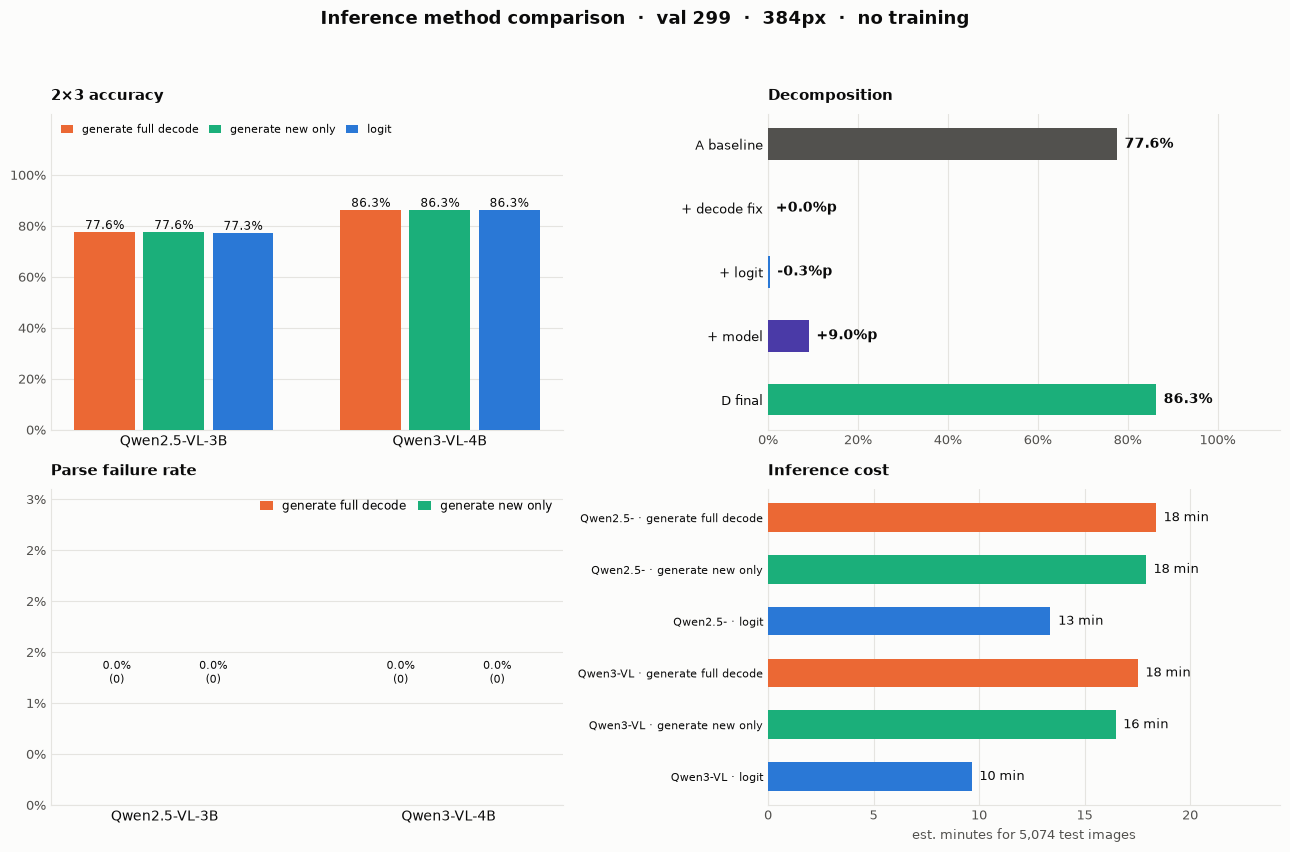

저장: bakeoff_out/infer_method.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import ft2font
from matplotlib.ticker import PercentFormatter

def _has_hangul(p):
    try: return ft2font.FT2Font(p).get_char_index(ord("한")) != 0
    except Exception: return False

def setup_korean_font():
    known = [r"C:\Windows\Fonts\malgun.ttf", r"C:\Windows\Fonts\malgunbd.ttf",
             "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
             "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
             "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"]
    prefer = ["malgun", "nanum", "apple sd gothic", "applegothic", "noto sans cjk",
              "noto sans kr", "source han sans", "pretendard", "gulim", "gothic"]
    avoid  = ["unifont", "sample", "symbol", "emoji"]
    def reg(p):
        fm.fontManager.addfont(p)
        n = fm.FontProperties(fname=p).get_name(); plt.rcParams["font.family"] = n
        print(f"[font] {n}"); return n
    for p in known:
        if Path(p).exists() and _has_hangul(p): return reg(p)
    hits = []
    for ext in ("ttf", "otf"):
        for p in fm.findSystemFonts(fontext=ext):
            if not _has_hangul(p): continue
            try: n = fm.FontProperties(fname=p).get_name()
            except Exception: continue
            low = (n + " " + Path(p).name).lower()
            hits.append((2 if any(b in low for b in avoid) else
                         (0 if any(g in low for g in prefer) else 1), p))
    if hits:
        hits.sort(key=lambda h: h[0]); return reg(hits[0][1])
    return None

KO = setup_korean_font() is not None
plt.rcParams["axes.unicode_minus"] = False
def T(ko, en): return ko if KO else en

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
C_FULL, C_NEW, C_LOG = "#eb6834", "#1baf7a", "#2a78d6"   # 검증된 카테고리 팔레트

def tidy(ax, axis="y"):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, length=0, labelsize=9)
    ax.grid(axis=axis, color=GRID, lw=.8, zorder=0); ax.set_axisbelow(True)

M_KO = {"generate_full": "generate\n전체디코딩", "generate_new": "generate\n새토큰만",
        "logit": "로짓 비교"}
M_EN = {"generate_full": "generate\nfull decode", "generate_new": "generate\nnew only",
        "logit": "logit"}
MC = {"generate_full": C_FULL, "generate_new": C_NEW, "logit": C_LOG}

fig, axes = plt.subplots(2, 2, figsize=(13, 8.6), facecolor=SURFACE)
fig.suptitle(T(f"추론 방식 비교  ·  val {len(val_df)}장  ·  {IMAGE_SIZE}px  ·  {GPU_NAME}  ·  학습 없음",
               f"Inference method comparison  ·  val {len(val_df)}  ·  {IMAGE_SIZE}px  ·  no training"),
             fontsize=13, fontweight="bold", color=INK, y=.985)

# 1. 2×3 정확도
ax = axes[0, 0]; tidy(ax)
labels = ["Qwen2.5-VL-3B", "Qwen3-VL-4B"]
x = np.arange(2); w = .26
for i, m in enumerate(METHODS):
    vals = [G(K25, m)["acc"], G(K3, m)["acc"]]
    xs = x + (i - 1) * w
    ax.bar(xs, vals, w * .88, label=T(M_KO[m], M_EN[m]).replace("\n", " "),
           color=MC[m], zorder=3)
    for xx, v in zip(xs, vals):
        ax.text(xx, v + .012, f"{v:.1%}", ha="center", fontsize=8.5, color=INK)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10, color=INK)
ax.set_ylim(0, 1.24); ax.set_yticks([0, .2, .4, .6, .8, 1.0])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.legend(fontsize=8, frameon=False, loc="upper left", ncol=3,
          columnspacing=.9, handlelength=1.1)
ax.set_title(T("2×3 정확도", "2×3 accuracy"), fontsize=11, fontweight="bold",
             color=INK, loc="left", pad=10)

# 2. 개선폭 분해
ax = axes[0, 1]; tidy(ax, axis="x")
steps = [(T("A 배포 베이스라인 원본", "A baseline"), A["acc"], INK2, False),
         (T("+ 디코딩 버그 수정", "+ decode fix"), Ap["acc"]-A["acc"], C_NEW, True),
         (T("+ 로짓 방식 전환", "+ logit"), B["acc"]-Ap["acc"], C_LOG, True),
         (T("+ 모델 교체", "+ model"), D["acc"]-B["acc"], "#4a3aa7", True),
         (T("D 최종 채택", "D final"), D["acc"], "#1baf7a", False)]
y = np.arange(len(steps))[::-1]
ax.barh(y, [abs(v) for _, v, _, _ in steps], height=.5,
        color=[c for _, _, c, _ in steps], zorder=3)
mx = max(abs(v) for _, v, _, _ in steps)
for yy, (nm, v, _, is_delta) in zip(y, steps):
    ax.text(abs(v) + mx*.02, yy, f"{v:+.1%}p" if is_delta else f"{v:.1%}",
            va="center", fontsize=10, fontweight="bold", color=INK)
ax.set_yticks(y); ax.set_yticklabels([nm for nm, _, _, _ in steps], fontsize=9, color=INK)
ax.set_xlim(0, mx * 1.32)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_title(T("개선폭 분해 — 총 개선폭이 어디서 왔나", "Decomposition"),
             fontsize=11, fontweight="bold", color=INK, loc="left", pad=10)

# 3. 파싱 실패
ax = axes[1, 0]; tidy(ax)
gen_methods = ["generate_full", "generate_new"]
x = np.arange(2); w = .34
for i, m in enumerate(gen_methods):
    fr = [1 - G(K25, m)["parse_ok_rate"], 1 - G(K3, m)["parse_ok_rate"]]
    xs = x + (i - .5) * w
    ax.bar(xs, fr, w * .88, label=T(M_KO[m], M_EN[m]).replace("\n", " "),
           color=MC[m], zorder=3)
    for xx, v, kk in zip(xs, fr, (K25, K3)):
        ax.text(xx, v + .012, f"{v:.1%}\n({G(kk,m)['n_failed']})",
                ha="center", fontsize=8, color=INK)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10, color=INK)
top = max(1 - G(k, m)["parse_ok_rate"] for k in (K25, K3) for m in gen_methods)
ax.set_ylim(0, max(top, .02) * 1.55)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.legend(fontsize=8.5, frameon=False, loc="upper right", ncol=2,
          columnspacing=1.0, handlelength=1.1)
ax.set_title(T("파싱 실패율  ·  실패하면 무조건 'a'로 찍힘",
               "Parse failure rate"), fontsize=11, fontweight="bold",
             color=INK, loc="left", pad=10)

# 4. 속도
ax = axes[1, 1]; tidy(ax, axis="x")
rows_ = [G(k, m) for k in (K25, K3) for m in METHODS]
y = np.arange(len(rows_))[::-1]
mins = [r["sec_per_sample"] * 5074 / 60 for r in rows_]
ax.barh(y, mins, height=.55, color=[MC[r["method"]] for r in rows_], zorder=3)
for yy, m_, r in zip(y, mins, rows_):
    ax.text(m_ + max(mins)*.02, yy, f"{m_:.0f}분" if KO else f"{m_:.0f} min",
            va="center", fontsize=9, color=INK)
ax.set_yticks(y)
ax.set_yticklabels([f"{r['label'][:8]} · {T(M_KO,M_EN)[r['method']]}".replace("\n", " ")
                    for r in rows_], fontsize=8, color=INK)
ax.set_xlim(0, max(mins) * 1.32)
ax.set_xlabel(T("test 5,074장 추론 예상 시간 (분)",
                "est. minutes for 5,074 test images"), fontsize=9, color=INK2)
ax.set_title(T("추론 비용", "Inference cost"), fontsize=11, fontweight="bold",
             color=INK, loc="left", pad=10)

plt.tight_layout(rect=[0, 0, 1, .95])
plt.savefig(OUT_DIR / "infer_method.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print("저장:", OUT_DIR / "infer_method.png")

---
## 10. 요약 저장 & 해석


In [12]:
summary = {
    "n_val": len(val_df), "image_size": IMAGE_SIZE, "gpu": GPU_NAME,
    "dtype": str(DTYPE).split(".")[-1], "gen_max_new_tokens": GEN_MAX_NEW_TOKENS,
    "cells": {f"{r['model_key']}|{r['method']}":
              {k: r[k] for k in ("label","method","acc","by_type","pred_dist",
                                 "sec_per_sample","parse_ok_rate","n_failed")}
              for r in results.values()},
    "decomposition": {
        "A_baseline_original":  A["acc"],
        "decode_fix":           Ap["acc"] - A["acc"],
        "logit_switch":         B["acc"]  - Ap["acc"],
        "model_swap":           D["acc"]  - B["acc"],
        "D_final":              D["acc"],
        "total":                D["acc"]  - A["acc"],
        "decode_fix_on_qwen3":  Cp["acc"] - C["acc"],
        "logit_switch_on_qwen3": D["acc"] - Cp["acc"],
    },
}
json.dump(summary, open(OUT_DIR / "infer_method_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
print("저장:", OUT_DIR / "infer_method_summary.json")

d_dec, d_log, d_mod = Ap["acc"]-A["acc"], B["acc"]-Ap["acc"], D["acc"]-B["acc"]
print("\n" + "="*68)
print(f"총 개선폭 {D['acc']-A['acc']:+.1%}p 의 내역")
print(f"  디코딩 버그 수정 {d_dec:+.1%}p · 로짓 전환 {d_log:+.1%}p · 모델 교체 {d_mod:+.1%}p")
print("-"*68)
if d_dec >= 0.02:
    print(f"→ 배포 베이스라인의 디코딩 버그가 {d_dec:.1%}p를 깎아먹고 있었습니다.")
    print(f"  파싱 실패 {A['n_failed']}건이 전부 'a'로 찍힌 결과입니다.")
    print("  보고서의 '모델 교체로 +9.0%p'는 방식 고정 비교라 그대로 유효하지만,")
    print("  배포 베이스라인 대비 총 개선폭은 그보다 큽니다.")
else:
    print("→ 디코딩 버그의 실측 영향은 작았습니다. 프롬프트 말미 형태 덕에")
    print("  마지막 줄 파싱이 우연히 잘 맞은 경우입니다. 다만 우연에 기대는 구조이므로")
    print("  새 토큰만 잘라 디코딩하는 편이 안전합니다.")
if abs(d_log) < 0.01:
    print("→ 로짓 전환의 정확도 이득은 미미합니다. 가치는 속도와 확률 부산물에 있습니다.")
else:
    print(f"→ 로짓 전환만으로 {d_log:+.1%}p.")
print("="*68)

저장: bakeoff_out/infer_method_summary.json

총 개선폭 +8.7%p 의 내역
  디코딩 버그 수정 +0.0%p · 로짓 전환 -0.3%p · 모델 교체 +9.0%p
--------------------------------------------------------------------
→ 디코딩 버그의 실측 영향은 작았습니다. 프롬프트 말미 형태 덕에
  마지막 줄 파싱이 우연히 잘 맞은 경우입니다. 다만 우연에 기대는 구조이므로
  새 토큰만 잘라 디코딩하는 편이 안전합니다.
→ 로짓 전환의 정확도 이득은 미미합니다. 가치는 속도와 확률 부산물에 있습니다.


---
### 결과 파일

- `bakeoff_out/infer_<모델>_<방식>.json` — 조건별 예측·정확도·파싱 실패 (재실행 시 자동 재사용)
- `bakeoff_out/infer_method_summary.json` — 2×2 요약과 효과 분해
- `bakeoff_out/infer_method.png` — 4패널 그림

### 읽는 법

**방식 기여(B−A)가 크다면** — 배포 베이스라인 대비 개선폭의 일부는 모델이 아니라 파싱 안정성에서 온 것입니다.
보고서의 "모델 교체로 +9.0%p" 서술은 그대로 유효하지만(방식 고정 비교), *배포 베이스라인 대비 총 개선폭*은 그보다 큽니다.

**방식 기여가 0에 가깝다면** — 파싱이 잘 되고 있었다는 뜻이고, 로짓 비교의 가치는 정확도가 아니라
**속도와 부산물(확률)** 에 있습니다. 그래도 로짓 방식을 유지할 이유는 충분합니다: 5,074장 추론에서
파싱 실패가 단 한 건만 나도 그 행은 버려지는 셈이고, 확률값이 없으면 이번 같은 사후 분석이 불가능합니다.
